# Notebook 1 : Exploratory Data Analysis (EDA)

**Goal:** Understand the raw dataset before touching it.
We only look here — no cleaning, no changes, no saving.

**Dataset:** Cleveland Heart Disease (UCI)  
**Target:** `condition` → 0 = No Disease, 1 = Disease

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Make sure static folder exists for saving plots
os.makedirs('../App/static', exist_ok=True)

# Load RAW data — do not modify
df = pd.read_csv('../Data/heart_cleveland_upload.csv')
print('✅ Data loaded successfully')
print(f'   Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Data loaded successfully
   Shape: 297 rows × 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


## 1. Basic Dataset Information

In [2]:
print('── COLUMN DATA TYPES ──────────────────────')
print(df.dtypes)
print()
print('── MISSING VALUES ─────────────────────────')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')
print()
print('── DUPLICATE ROWS ─────────────────────────')
print(f'Duplicate rows: {df.duplicated().sum()}')

── COLUMN DATA TYPES ──────────────────────
age            int64
sex            int64
cp             int64
trestbps       int64
chol           int64
fbs            int64
restecg        int64
thalach        int64
exang          int64
oldpeak      float64
slope          int64
ca             int64
thal           int64
condition      int64
dtype: object

── MISSING VALUES ─────────────────────────
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

Total missing values: 0

── DUPLICATE ROWS ─────────────────────────
Duplicate rows: 0


In [3]:
print('── STATISTICAL SUMMARY ────────────────────')
df.describe().round(2)

── STATISTICAL SUMMARY ────────────────────


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00
mean,54.54,0.68,2.16,131.69,247.35,0.14,1.00,149.60,0.33,1.06,0.60,0.68,0.84,0.46
std,9.05,0.47,0.96,17.76,52.00,0.35,0.99,22.94,0.47,1.17,0.62,0.94,0.96,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,2.00,120.00,211.00,0.00,0.00,133.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,56.00,1.00,2.00,130.00,243.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,0.00,0.00
75%,61.00,1.00,3.00,140.00,276.00,0.00,2.00,166.00,1.00,1.60,1.00,1.00,2.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,3.00,2.00,1.00


## 2. Feature Dictionary

Understanding what each column means before analysing it.

In [4]:
feature_info = {
    'age'     : 'Age in years',
    'sex'     : '1 = Male, 0 = Female',
    'cp'      : 'Chest pain type: 0=Typical Angina, 1=Atypical Angina, 2=Non-anginal, 3=Asymptomatic',
    'trestbps': 'Resting blood pressure (mmHg)',
    'chol'    : 'Serum cholesterol (mg/dl)',
    'fbs'     : 'Fasting blood sugar > 120 mg/dl (1=True, 0=False)',
    'restecg' : 'Resting ECG: 0=Normal, 1=ST-T abnormality, 2=LV hypertrophy',
    'thalach' : 'Maximum heart rate achieved',
    'exang'   : 'Exercise induced angina (1=Yes, 0=No)',
    'oldpeak' : 'ST depression induced by exercise relative to rest',
    'slope'   : 'Slope of peak exercise ST segment: 0=Upsloping, 1=Flat, 2=Downsloping',
    'ca'      : 'Number of major vessels coloured by fluoroscopy (0-3)',
    'thal'    : 'Thalassemia: 0=Normal, 1=Fixed defect, 2=Reversible defect',
    'condition': 'TARGET: 0=No heart disease, 1=Heart disease'
}

for col, desc in feature_info.items():
    print(f'  {col:<12} : {desc}')

  age          : Age in years
  sex          : 1 = Male, 0 = Female
  cp           : Chest pain type: 0=Typical Angina, 1=Atypical Angina, 2=Non-anginal, 3=Asymptomatic
  trestbps     : Resting blood pressure (mmHg)
  chol         : Serum cholesterol (mg/dl)
  fbs          : Fasting blood sugar > 120 mg/dl (1=True, 0=False)
  restecg      : Resting ECG: 0=Normal, 1=ST-T abnormality, 2=LV hypertrophy
  thalach      : Maximum heart rate achieved
  exang        : Exercise induced angina (1=Yes, 0=No)
  oldpeak      : ST depression induced by exercise relative to rest
  slope        : Slope of peak exercise ST segment: 0=Upsloping, 1=Flat, 2=Downsloping
  ca           : Number of major vessels coloured by fluoroscopy (0-3)
  thal         : Thalassemia: 0=Normal, 1=Fixed defect, 2=Reversible defect
  condition    : TARGET: 0=No heart disease, 1=Heart disease


## 3. Target Variable — Class Balance

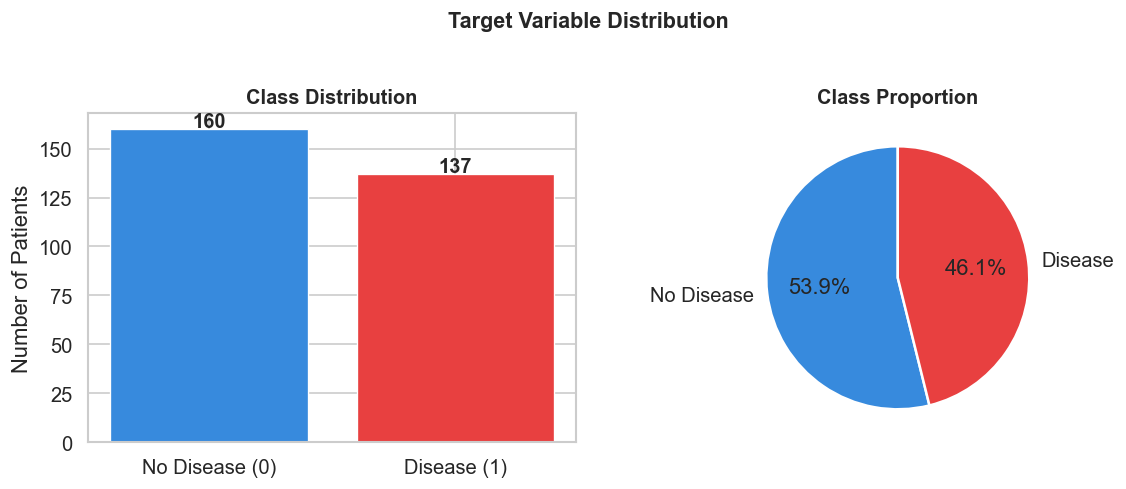

Class 0 (No Disease): 160 patients (53.9%)
Class 1 (Disease):    137 patients (46.1%)
Imbalance ratio: 1.17

→ Mild imbalance. SMOTE will be applied later during modelling (on training set only).


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['condition'].value_counts()
labels = ['No Disease (0)', 'Disease (1)']
colors = ['#378add', '#e84040']

# Bar chart
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Class Distribution', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Number of Patients')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(counts.values, labels=['No Disease', 'Disease'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Class Proportion', fontweight='bold', fontsize=12)

plt.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../App/static/plot_class_balance.png', bbox_inches='tight')
plt.show()

ratio = counts[0] / counts[1]
print(f'Class 0 (No Disease): {counts[0]} patients ({counts[0]/len(df)*100:.1f}%)')
print(f'Class 1 (Disease):    {counts[1]} patients ({counts[1]/len(df)*100:.1f}%)')
print(f'Imbalance ratio: {ratio:.2f}')
print(f'\n→ Mild imbalance. SMOTE will be applied later during modelling (on training set only).')

## 4. Age Distribution by Disease Status

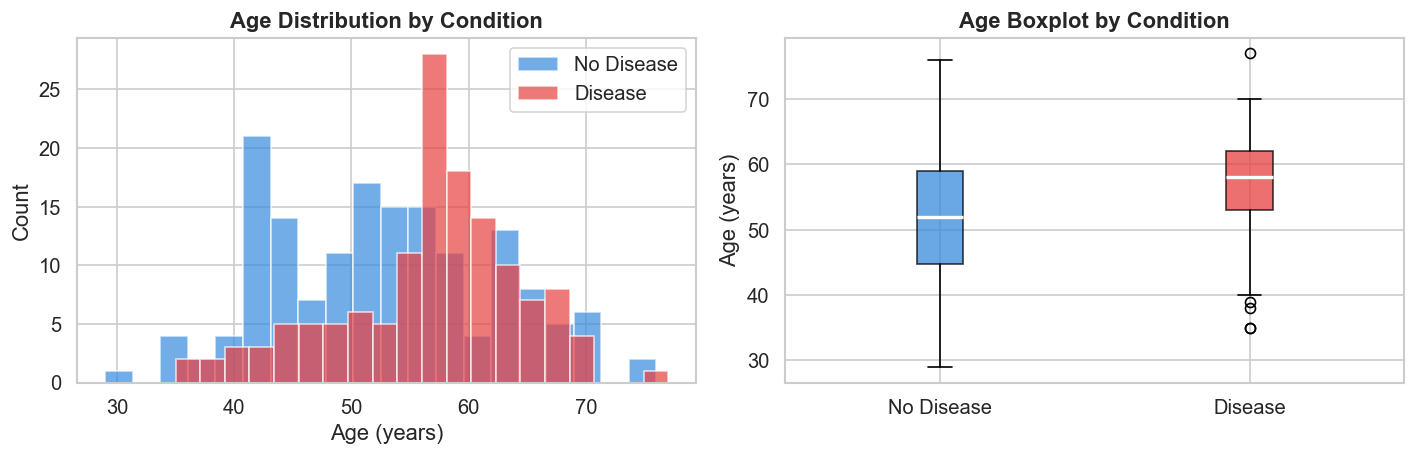

Mean age — No Disease: 52.6
Mean age — Disease:    56.8
→ Disease patients are on average older.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for val, label, color in [(0, 'No Disease', '#378add'), (1, 'Disease', '#e84040')]:
    axes[0].hist(df[df['condition'] == val]['age'], bins=20,
                 alpha=0.7, label=label, color=color, edgecolor='white')
axes[0].set_title('Age Distribution by Condition', fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

bp = axes[1].boxplot(
    [df[df['condition']==0]['age'], df[df['condition']==1]['age']],
    patch_artist=True, labels=['No Disease', 'Disease'],
    medianprops=dict(color='white', linewidth=2)
)
for patch, color in zip(bp['boxes'], ['#378add', '#e84040']):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title('Age Boxplot by Condition', fontweight='bold')
axes[1].set_ylabel('Age (years)')

plt.tight_layout()
plt.savefig('../App/static/plot_age_dist.png', bbox_inches='tight')
plt.show()

print(f'Mean age — No Disease: {df[df.condition==0].age.mean():.1f}')
print(f'Mean age — Disease:    {df[df.condition==1].age.mean():.1f}')
print('→ Disease patients are on average older.')

## 5. Correlation Heatmap

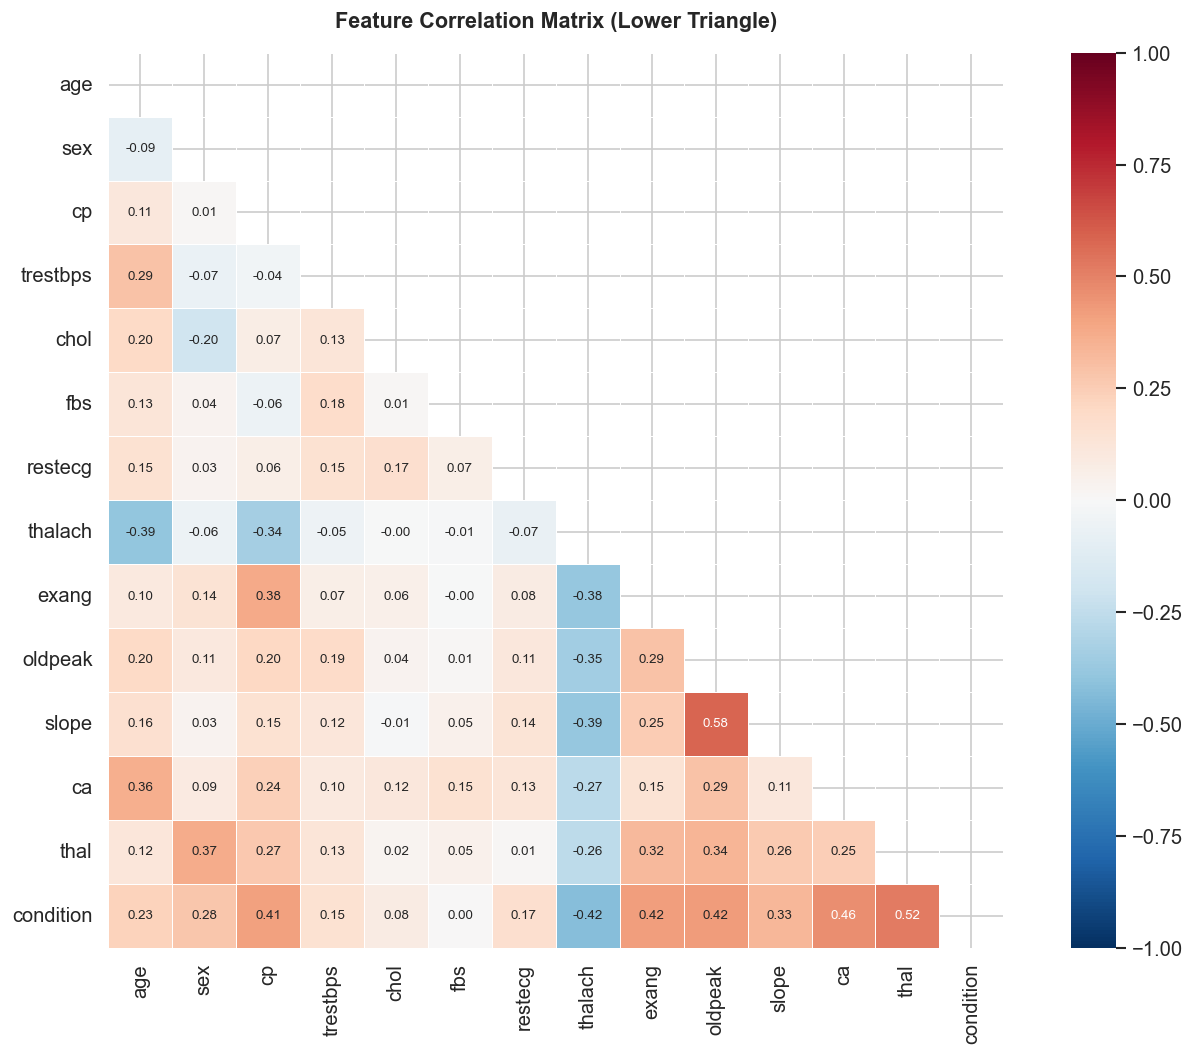

── Top correlations with TARGET (condition) ──
  thal        : 0.521  (positive)
  ca          : 0.463  (positive)
  oldpeak     : 0.424  (positive)
  thalach     : 0.424  (negative)
  exang       : 0.421  (positive)
  cp          : 0.409  (positive)
  slope       : 0.333  (positive)
  sex         : 0.278  (positive)
  age         : 0.227  (positive)
  restecg     : 0.166  (positive)
  trestbps    : 0.153  (positive)
  chol        : 0.080  (positive)
  fbs         : 0.003  (positive)


In [7]:
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix (Lower Triangle)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../App/static/plot_correlation.png', bbox_inches='tight')
plt.show()

print('── Top correlations with TARGET (condition) ──')
target_corr = corr['condition'].drop('condition').abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    direction = '(positive)' if corr['condition'][feat] > 0 else '(negative)'
    print(f'  {feat:<12}: {val:.3f}  {direction}')

## 6. Numerical Features — Distributions & Outlier Check

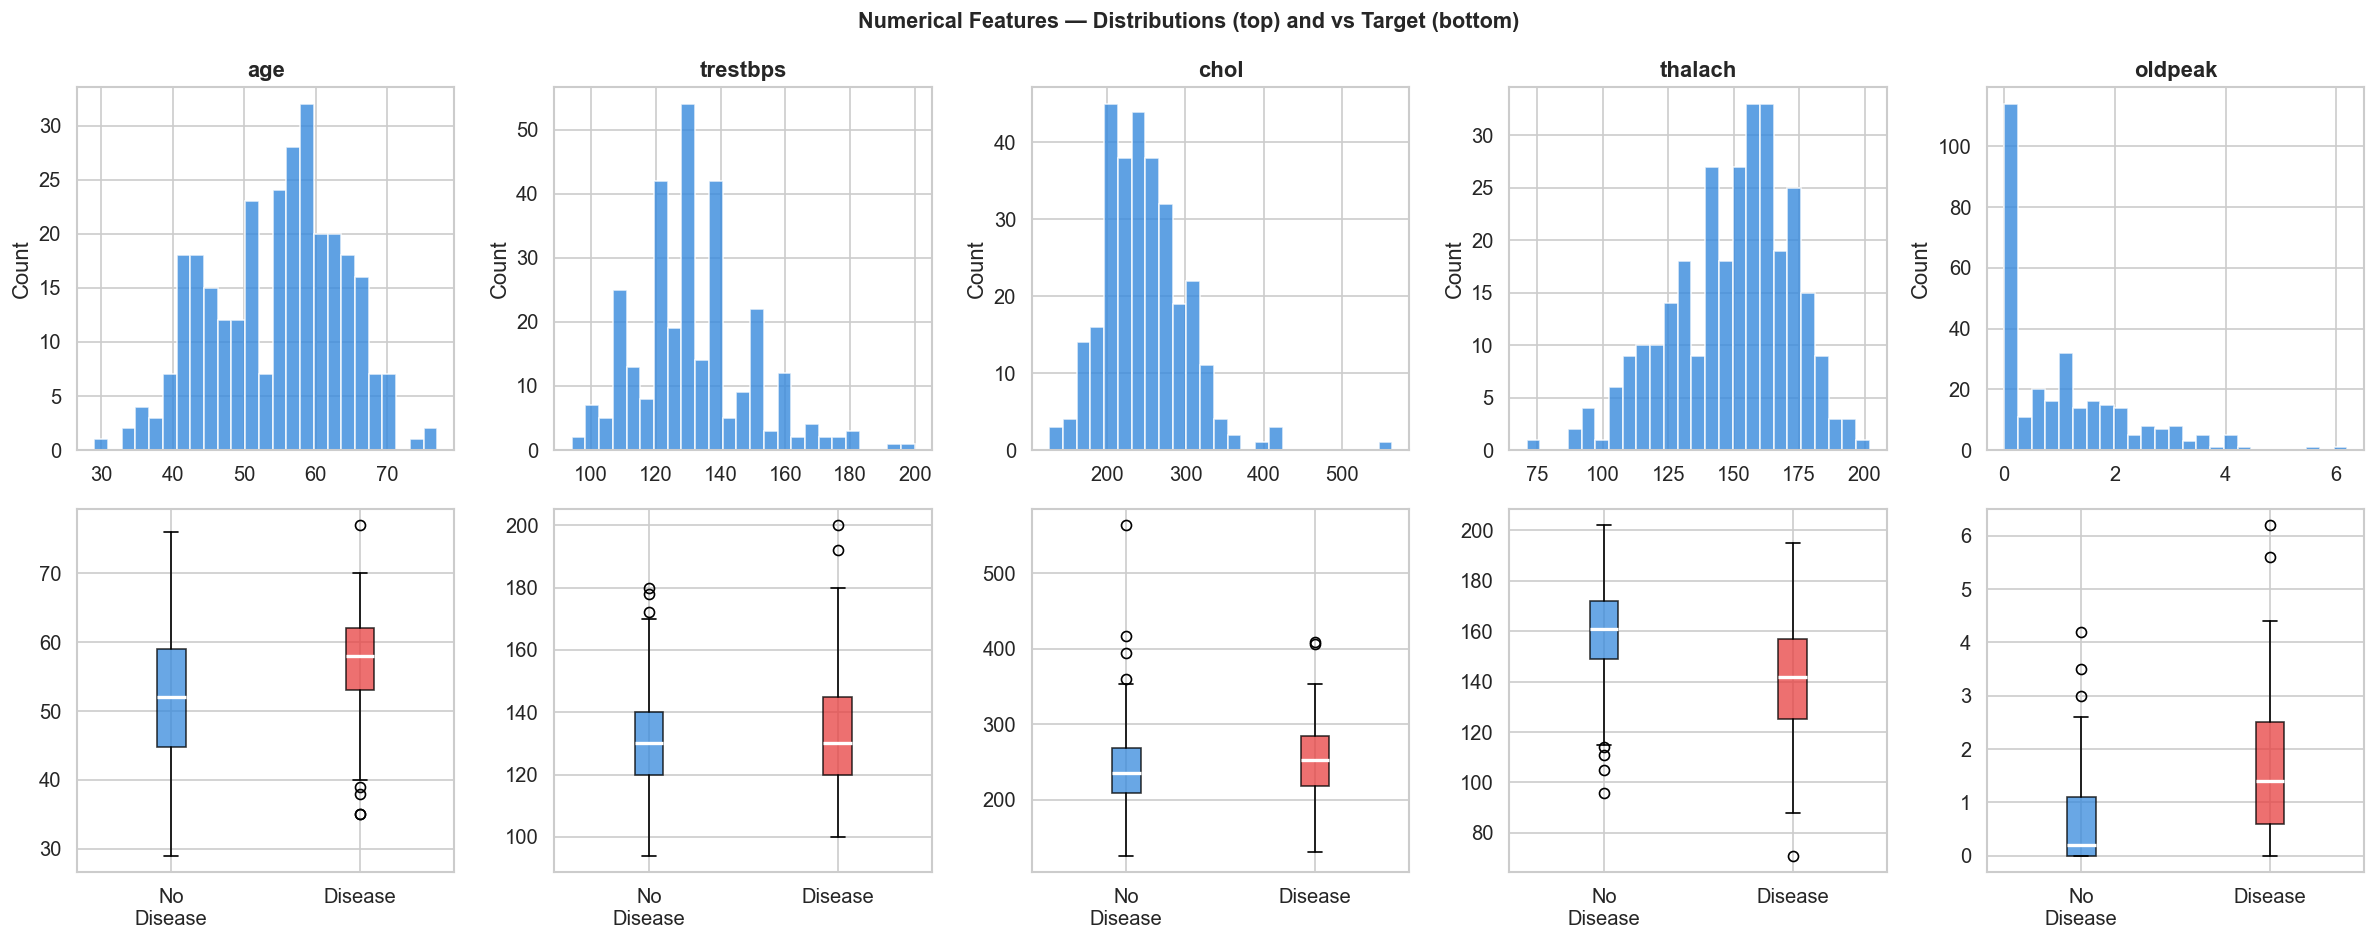

── Potential Outliers (IQR method) ──
  age         : 0 outliers
  trestbps    : 9 outliers
  chol        : 5 outliers
  thalach     : 1 outliers
  oldpeak     : 5 outliers


In [8]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, col in enumerate(num_cols):
    # Histogram top row
    axes[0, i].hist(df[col], bins=25, color='#378add', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(col, fontweight='bold')
    axes[0, i].set_ylabel('Count')

    # Boxplot bottom row — split by condition
    bp = axes[1, i].boxplot(
        [df[df['condition']==0][col], df[df['condition']==1][col]],
        patch_artist=True, labels=['No\nDisease', 'Disease'],
        medianprops=dict(color='white', linewidth=2)
    )
    for patch, c in zip(bp['boxes'], ['#378add', '#e84040']):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)

plt.suptitle('Numerical Features — Distributions (top) and vs Target (bottom)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../App/static/plot_numerical.png', bbox_inches='tight')
plt.show()

# IQR outlier count per column
print('── Potential Outliers (IQR method) ──')
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'  {col:<12}: {len(outliers)} outliers')

## 7. Categorical Features — Count Plots vs Target

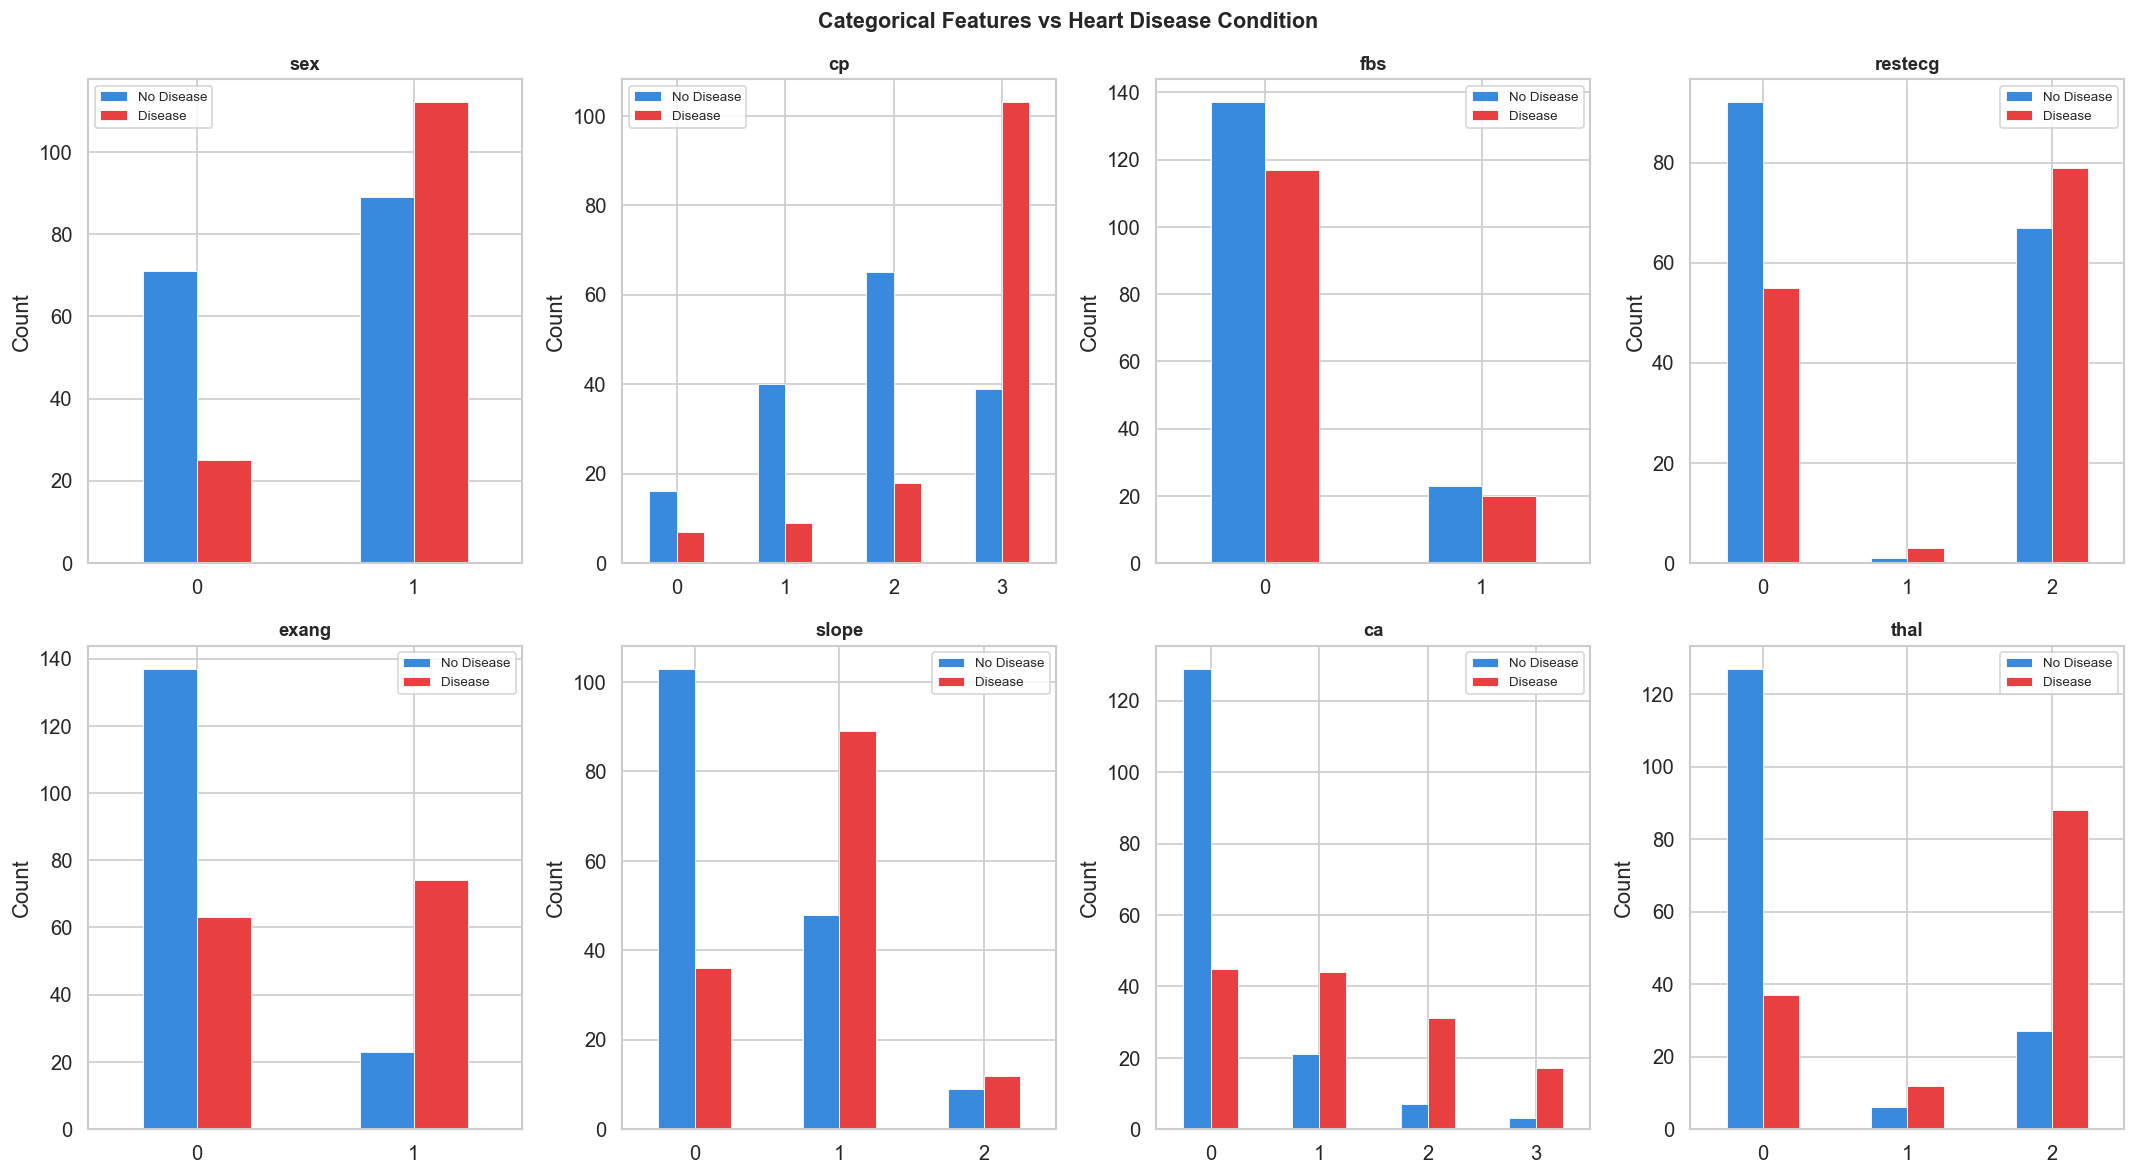

In [9]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    cross = pd.crosstab(df[col], df['condition'])
    cross.columns = ['No Disease', 'Disease']
    cross.plot(kind='bar', ax=ax, color=['#378add', '#e84040'],
               edgecolor='white', linewidth=0.5, rot=0)
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.set_ylabel('Count')

plt.suptitle('Categorical Features vs Heart Disease Condition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../App/static/plot_categorical.png', bbox_inches='tight')
plt.show()

## 8. EDA Summary — Key Findings

In [10]:
print('═'*55)
print('  EDA KEY FINDINGS')
print('═'*55)
print(f'  Rows          : {df.shape[0]}')
print(f'  Columns       : {df.shape[1]} (13 features + 1 target)')
print(f'  Missing values: {df.isnull().sum().sum()} ← none to handle')
print(f'  Duplicates    : {df.duplicated().sum()} ← none to handle')
print(f'  Class balance : {dict(df["condition"].value_counts())} ← mild imbalance')
print()
print('  Top 5 features correlated with heart disease:')
top5 = df.corr()['condition'].drop('condition').abs().sort_values(ascending=False).head(5)
for i, (feat, val) in enumerate(top5.items(), 1):
    print(f'    {i}. {feat:<12} → {val:.3f}')
print()
print('  Outliers found in: chol (1), trestbps (2), oldpeak (2)')
print('  → Will handle in Notebook 2: Preprocessing')
print()
print('  Next step → Run 02_Preprocessing.ipynb')
print('═'*55)

═══════════════════════════════════════════════════════
  EDA KEY FINDINGS
═══════════════════════════════════════════════════════
  Rows          : 297
  Columns       : 14 (13 features + 1 target)
  Missing values: 0 ← none to handle
  Duplicates    : 0 ← none to handle
  Class balance : {0: 160, 1: 137} ← mild imbalance

  Top 5 features correlated with heart disease:
    1. thal         → 0.521
    2. ca           → 0.463
    3. oldpeak      → 0.424
    4. thalach      → 0.424
    5. exang        → 0.421

  Outliers found in: chol (1), trestbps (2), oldpeak (2)
  → Will handle in Notebook 2: Preprocessing

  Next step → Run 02_Preprocessing.ipynb
═══════════════════════════════════════════════════════
